# 멀티모달 대규모 언어 모델

- 모달리티(데이터의 유형, 형태)라고 부르는 텍스트와 이미지를 다룰 수 있는 모델을 멀티모달이라 부릅니다.
- 이미지, 오디오, 비디오, 센서 데이터와 같이 여러 종류(모달리티)의 데이터를 다룰 수 있는 모델을 멀티모달이라 부릅니다. 한 모달리티를 입력을 받을 수 있지만 행당 모달리티로 출력을 생성하지 못할 수 있습니다.


## 비전 트랜스포머

- 비전 트랜스포머(ViT)는 합성곱 신경망(CNN)에 비해 이미지 인식 작업에서 매우 잘 동작한다는 것이 입증되었습니다.
- https://arxiv.org/abs/2010.11929
- 원본 트랜스포머처럼 ViT를 사용해 비정형 데이터인 이미지를 분류와 같은 다양한 작업에 사용할 수 있는 표현으로 바꿀수 있습니다.
- ViT 트랜스포머 구조의 핵심 구성요소인 인코더에 의존합니다.
- 인코더는 텍스트 입력을 디코더에 전달하기 전에 수치 표현으로 바꾸는 역할을 합니다.
- 하지만 인코더가 제 역할을 수행하기 전에 텍스트 입력이 먼저 토큰으로 바뀌어야 합니다.


- 이미지는 단어로 구성되지 않았기 때문에 토큰화 단계를 비전 데이터에 사용할 수 없습니다.
- 대신 ViT 저자들은 이미지를 '단어'로 토큰화하는 방법을 만들었습니다.
- 이를 통해 원본 인코더 구조를 사용할 수 있습니다.


- 고양이 이미지가 있다고 가정해보죠.
- 이 이미지는 여러 개의 픽셀로 표현됩니다.
- 예를 들어 512x512 픽셀 이미지가 있다고 가정해봅시다.
- 각 개별 픽셀은 많은 정보를 담고 있지 않지만 픽셀의 패치를 연결하면 점차 더 많은 정보가 드러나기 시작합니다.


- ViT는 이와 유사한 원리를 사용합니다.
- 텍스트를 토큰으로 분할하는 것처럼 원본 이미지를 이미지 패치로 변환합니다.
- 이미지를 수평과 수직 방향으로 여러개의 조각으로 자릅니다.


- 텍스트를 토큰으로 변환하는 걱처럼 이미지를 이미지의 패치로 바꿉니다.
- 이미지 패치를 펼친 입력을 텍스트에 있는 토큰으로 생각할 수 있습니다.
- 하지만 각 패치에 고유한 ID를 할당할 수 없습니다.
- 텍스트 어휘사전에 있는 토큰과 달리 이런 패치는 다른 이미지에 나타나는 경우가 거의 없기 때문입니다.


- 그 대신 패치를 선형적으로 임베딩하여 수치 표현, 즉 임베딩을 만듭니다.
- 이를 트랜스포머 모델의 입력으로 사용합니다.
- 이런 식으로 이미지 패치를 토큰과 동일한 방식으로 다룹니다.


- 원본 ViT 모델은 16x16크기의 패치를 사용합니다.
- 이 방식에서 흥미로운 점은 이 임베딩이 인코더로 전달되면 텍스트 토큰처럼 처리된다는 것입니다.
- 이 시점부터 텍스트와 이미지를 훈련하는 방식에 차이가 없습니다.
- 이런 유사성으로 인해 ViT를 온갖 종류의 언어 모델을 멀티모달로 만드는 데 사용합니다.
- 이를 사용하는 매우 간단한 방법 하나는 임베딩 모델의 훈련 과정에 추가하는 것입니다.
- ViT 구현은 이미지 패치를 직접 나누고 밀집 층을 사용해 임베딩을 만듭니다. 요즘 비전 트랜스포머 모델은 필터와 스트라이드가 패치 크기와 같고 출력 채널이 임베딩 크기와 같은 합성곱 층을 사용하여 패치 임베딩을 만드는 경우가 많습니다.


## 멀티모달 임베딩 모델

- 멀티모달 임베딩 모델은 동일한 벡터 공간 안에 여러 모달리티를 위한 임베딩을 만들수 있습니다.
- 만들어진 임베딩이 동일한 벡터 공간에 놓이기 때문에 멀티모달 표현을 비교할 수 있다는 것이 장점입니다.
- 예를들면 멀티모달 임베딩 모델을 사용하면 입력 텍스트를 기반으로 이미지를 찾을 수 있습니다.
- 이는 질문과 관련성이 가장 높은 문서를 찾는 작업과 비슷합니다.
- 멀티모달 임베딩 모델이 많지만 가장 유명하고 널리 사용되는 모델은 CLIP(Contrastive Language-Image Pre-training)입니다.


### CLIP: 텍스트와 이미지 연결

- CLIP은 이미지와 텍스트 임베딩을 모두 계산할 수 있는 임베딩 모델입니다.
- 만들어진 임베딩은 동일한 벡터 공간에 놓입니다.
- 이미지 임베딩을 텍스트 임베딩과 비교할 수 있다는 의미입니다.
- 제로샷 분류: 이미지 임베딩을 후보 클래스 설명의 임베딩과 비교하여 가장 비슷한 클래스를 찾을 수 있습니다.
- 클러스터링: 키워드가 어떤 이미지 집합에 속하는지 찾기 위해 이미지와 키워드 집합을 클러스터로 모읍니다.
- 검색: 수십억 개의 텍스트 또는 이미지에서 입력 텍스트나 이미지에 관련된 결과를 빠르게 찾습니다.
- 생성: 이미지 생성(예를 들어 스테이블 디퓨전)에 멀티모달 임베딩을 사용합니다.


### CLIP이 멀티모달 임베딩을 생성하는 방법

- CLIP의 작동 방식은 실제로 매우 간단합니다.
- 수백만 개의 이미지와 캡션으로 구성된 데이터셋이 있다고 상상해보죠
- 이 데이터셋을 사용해 이미지와 캡션에 대해 2개의 표현을 만들 수 있습니다.
- 이를 위해 CLIP은 텍스트 인코더를 사용해 텍스트를 임베딩하고 이미지 인코더를 사용해 이미지를 임베딩합니다.
- 생성된 임베딩 쌍을 코사인 유사도로 비교합니다.
- 훈련을 시작할 때 이미지 임베딩과 텍스트 임베딩 사이의 유사도는 매우 낮습니다.
- 훈련하는 동안 두 임베딩 사이의 유사도를 최적화합니다.
- 이방법을 대조학습이라 부릅니다.


### OpenCLIP

- https://github.com/mlfoundations/open_clip
- OpenCLIP 또는 다른 어떤 CLIP 모델을 사용한다는 것은 텍스트 입력과 이미지 입력을 처리하여 메인 모델로 보낸다는 의미입니다.


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

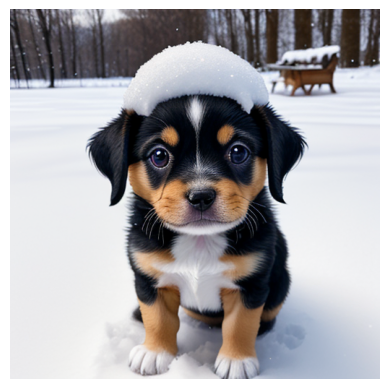

In [32]:
from urllib.request import urlopen
from PIL import Image
import matplotlib.pyplot as plt

puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image = Image.open(urlopen(puppy_path)).convert("RGB")

caption = "a puppy playing in the snow"

# 전처리된 이미지를 출력합니다.
plt.imshow(image)
plt.axis("off")

- 이 이미지의 캡션이 있으므로 OpenCLIP을 사용해 이미지와 텍스트의 임베딩을 모두 생성할 수 있습니다.
- 이를 위해 3개의 모델을 로드해야 합니다.
  - 텍스트 입력을 토큰화하기 위한 토크나이저
  - 이미지를 전처리하고 크기를 바꾸기 위한 전처리기
  - 위의 두 출력을 임베딩으로 바꾸는 메인 모델

- 허깅 페이스 transformers 라이브러리에서 제공하는 ~TokenizerFast 클래스는 러스트로 작성된 허깅 페이스의 tokenizer 라이브러리 기반으로 구현되었으며 파이썬 버전인 ~Tokenizer 클래스보다 성능이 뛰어납니다.
- 사실 CLIPProcessor가 CLIPTokenizerFast를 사용해 토큰화를 수행할 수 있기 때문에 토크나이저를 따로 로드할 필요는 없습니다.


In [ ]:
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel

model_id = "openai/clip-vit-base-patch32"

# 텍스트 전처리를 위한 토크나이저를 로드합니다.
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id)

# 이미지 전처리를 위한 전처리기를 로드합니다.
clip_processor = CLIPProcessor.from_pretrained(model_id)

# 텍스트 임베딩과 이미지 임베딩을 생성하기 위한 메인 모델
model = CLIPModel.from_pretrained(model_id)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1909.41it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# 입력을 토큰으로 나눕니다.
inputs = clip_tokenizer(caption, return_tensors="pt")
inputs

{'input_ids': tensor([[49406,   320,  6829,  1629,   530,   518,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

- 이 출력은 입력 ID를 담고 있는 딕셔너리 입니다.
- 이 ID가 무엇을 나타내는지 확인하기 위해 convert_ids_to_tokens 함수를 사용해 ID를 토큰으로 바꿀수 있습니다.


In [5]:
# 입력 ID를 토큰으로 되돌립니다.
clip_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

['<|startoftext|>',
 'a</w>',
 'puppy</w>',
 'playing</w>',
 'in</w>',
 'the</w>',
 'snow</w>',
 '<|endoftext|>']

- 이전에 자주 보았듯이 텍스트는 토큰으로 분할됩니다.
- 이미지 임베딩과 구분되도록 텍스트의 시작과 끝 토큰이 추가되었습니다.
- 결과중에 [CLS] 토큰이 없다는 것도 볼수 있습니다.
- CLIP에서 [CLS] 토큰은 이미지 임베딩을 표현하는데 사용됩니다.
  - CLIP 모델은 텍스트의 경우 마지막 토큰(EOS)의 임베딩을 사용하고, 이미지의 경우 첫번째 토큰(CLS)의 임베딩을 사용합니다.


In [ ]:
# 텍스트 임베딩을 만듭니다.
text_embedding = model.get_text_features(**inputs)
text_embedding_tensor = text_embedding.pooler_output
print(text_embedding_tensor.shape)

torch.Size([1, 512])


- 하나의 문자열에 대한 임베딩 결과는 512개의 값입니다.
- 이미지 임베딩을 만들기 전에 텍스트 임베딩을 만들 때처럼 전처리해야 합니다.
- 모델이 크기와 같은 속성을 가진 텐서 형태의 이미지를 기대하기 때문입니다.
- 이를 위해 앞서 로드한 clip_processor를 사용합니다.
  - 이와 비슷하게 다음처럼 text 매개변수에 캡션을 전달하여 토큰화를 수행할 수 있습니다.
  - inputs = clip_processor(text=caption, return_tensors='pt')


In [ ]:
import torch
import numpy as np

# 이미지를 전처리합니다.
processed_image = clip_processor(text=None, images=image, return_tensors="pt")[
    "pixel_values"
]

print(processed_image.shape)

torch.Size([1, 3, 224, 224])


- 원본 이미지 크기는 512x512 픽셀 입니다. 전처리하여 모델이 기대하는 224x224 크기로 줄였습니다.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

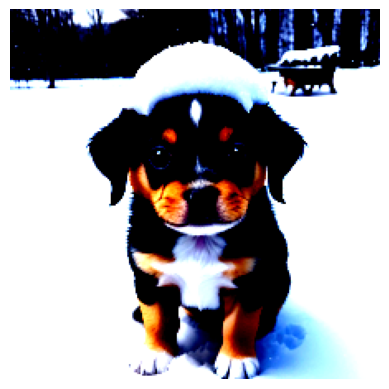

In [41]:
# matplotlib의 imshow는 (높이, 너비, 채널) 또는 (너비, 높이, 채널) 순서를 기대합니다.
# 따라서 차원 순서를 바꿔줘야 올바르게 이미지를 시각화할 수 있습니다.

import torch
import numpy as np
import matplotlib.pyplot as plt

# 시각화를 이해 이미지를 준비합니다.
# 첫번째 차원(크기 1)을 제거하여 3차원 텐서(채널, 높이, 너비)로 만듭니다.
img = processed_image.squeeze(0)

# 텐서의 차원 순서를 뒤집습니다. 예를들어 C,H,W -> W, H, C
# torch.arange는 2,1,0 처럼 역순 인덱스를 만듭니다.
img = img.permute(*torch.arange(img.ndim - 1, -1, -1))

# 차원순서를 (i,j,k) -> (j,i,k)로 바꿉니다.
# 첫번째와 두번째 차원을 맞바꿉니다. (W, H, C) -> (H, W, C)로 변환됩니다.
img = np.einsum("ijk->jik", img)

# # 전처리된 이미지를 출력합니다.
plt.imshow(img)
plt.axis("off")

- 전처리된 이미지를 임베딩으로 변환하려면 이전처럼 모델을 호출해야 합니다.


In [45]:
# 이미지 임베딩을 만듭니다.
image_embedding = model.get_image_features(processed_image)
image_embedding_tensor = image_embedding.pooler_output
print(image_embedding_tensor.shape)

torch.Size([1, 512])


- 이미지 임베딩의 크기가 텍스트 임베딩의 크기와 같습니다.
- 두 임베딩을 비교하고 비슷한지 확인할 수 있기 때문에 크기가 같다는 사실은 중요합니다.
- 두 임베딩을 사용해 얼마나 비슷한지 계산할 수 있습니다.


In [47]:
# 임베딩을 정규화합니다.
text_embedding_tensor /= text_embedding_tensor.norm(dim=-1, keepdim=True)
image_embedding_tensor /= image_embedding_tensor.norm(dim=-1, keepdim=True)

# 유사도를 계산합니다.
text_embedding_tensor = text_embedding_tensor.detach().cpu().numpy()
image_embedding_tensor = image_embedding_tensor.detach().cpu().numpy()
score = np.dot(text_embedding_tensor, image_embedding_tensor.T)
score

array([[0.3314964]], dtype=float32)

- 0.33이란 유사도 점수를 해석하기 어렵습니다.
- 모델이 생각하는 낮은 유사도 점수와 높은 유사도 점수에 대해 알지 못하기 때문입니다.
- 이 모델의 경우 0.33은 높은 점수 입니다.


### sentence-transformers를 사용해 CLIP 로드하기

- sentence-transformers는 임베딩을 훨씬 쉽게 만들 수 있는 CLIP 기반 모델을 몇 개 제공합니다.


In [ ]:
from sentence_transformers import SentenceTransformer, util

# SBERT 호환 CLIP 모델을 로드합니다.
model = SentenceTransformer("clip-ViT-B-32")

# 이미지를 인코딩합니다.
image_embeddings = model.encode(image)

# 캡션을 인코딩합니다.
text_embeddings = model.encode(caption)

# 코사인 유사도를 계산합니다.
sim_matrix = util.cos_sim(image_embeddings, text_embeddings)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1661.44it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: C:\Users\bbang\.cache\huggingface\hub\models--sentence-transformers--clip-ViT-B-32\snapshots\327ab6726d33c0e22f920c83f2ff9e4bd38ca37f\0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [50]:
print(sim_matrix)

tensor([[0.3315]])


## 텍스트 생성 모델을 멀티모달로 만들기

- 텍스트 생성 모델은 텍스트 표현을 해석하는 모델입니다.
- 멀티모달 텍스트 생성모델 특정 입력 이미지에 대해 추론할 수 있습니다.
- 두 도메인 사이의 간극을 메꾸기 위해 기존 모델에 멀티모달 기능을 추가하려는 시도가 있었습니다.


### BLIP-2: 모달리티 간극 메꾸기

- 밑바닥부터 멀티모달 언어 모델을 훈련하려면 엄청난 양의 이미지, 텍스트, 이미지-텍스트 쌍이 필요합니다.
- BLIP-2는 밑바닥부터 모델을 구축하는 대신 Q포머로 비전과 언어 사이의 간극을 메꿉니다.
- Q포머는 사전 훈련된 이미지 인코더와 사전 훈련된 LLM 사이에 다리를 연결합니다.
- 사전 훈련된 모델을 활용하므로 밑바닥부터 이미지 인코더와 LLM을 훈련할 필요 없이 BLIP-2는 다리만 훈련하면 됩니다.
- Q포머는 이들의 구조를 흉내냅니다. 어텐션 층을 공유하는 2개의 모듈로 구성됩니다.
  - 특성 추출을 위해 동결된 비전 트랜스포머와 상호작용하는 이미지 트랜스 포머
  - LLM과 상호작용할 수 있는 텍스트 트랜스포머
  - 실제로 Q포머는 BERT 기반 트랜스포머 모델의 하나입니다. 캡션 텍스트를 처리할 때는 크로스 어텐션을 건너뛰는 식으로 훈련하기 때문에 셀프 어텐션 층을 공유하는 2개의 하위 모듈로 생각할 수 있습니다. 크로스 어텐션은 짝수 번째 인코더에만 추가됩니다.


- Q포머는 모달리티마다 하나씩 2단계로 훈련됩니다.
- 1단계 이미지-문서 쌍을 사용해 이미지와 텍스트를 모두 표현하도록 Q포머를 훈련합니다.
- CLIP을 훈련할 때 보앗듯이 이 데이터 쌍은 일반적으로 이미지 캡션입니다.
- 이미지를 동결된 ViT에 주입하여 비전 임베딩을 얻습니다. 이 임베딩을 Q포머의 비전 트랜스포머를 위한 입력으로 사용합니다.
- 캡션은 Q포머의 텍스트 트랜스포머에 입력됩니다.


- 단계 1에서 표현 학습이 적용되어 비전과 언어 표현을 동시에 학습합니다.
- 단계 2에서 이 표현이 소프트 시각 프롬프트로 변환되어 LLM에 주입됩니다.
  - 소프트 프롬프트는 사람이 직접 입력한 하드 프롬프트가 아니라 임베딩 벡터 수준의 프롬프트를 의미합니다.


- 이런 입력을 사용해 Q포머는 3가지 작업에서 훈련됩니다.
  - 이미지-텍스트 대조 학습: 이 작업은 공동의 정보가 최대가 되도록 이미지 임베딩과 텍스트 임베딩 쌍을 정렬합니다.
  - 이미지-텍스트 매칭 : 이미지와 텍스트 쌍이 양성인지 음성인지 예측하는 분류작업입니다.
  - 이미지 기반 텍스트 생성 : 임력 이미지에서 추출한 정보를 바탕으로 텍스트를 생성하기 위해 모델을 훈련합니다.


- 이런 3개의 목적이 함께 최적화되어 ViT에서 추출한 시각 표현을 향상시킵니다.
- 어떤면에서는 나중에 LLM에 사용할 수 있도록 동력된 ViT의 임베딩에 텍스트 정보를 주입하는 것과 같습니다.


- 단계 1에서 얻은 학습 가능한 임베딩에는 텍스트 정보와 동일한 차원 공간에 시각 정보가 담깁니다.
- 단계 2에서 이 학습 가능한 임베딩을 LLM에게 전달합니다.
- 어떤 면에서 이 임베딩은 Q포머에서 추출한 시각 정보로 LLM에게 조건을 부여하는 소프트 시각 프롬프트로 동작합니다.
- 그 사이에는 학습 가능한 임베딩을 LLM이 기대하는 크기에 맞추기 위한 완전 연결층이 있습니다.
- 단계2에서는 Q포머에서 만든 학습 가능한 임베딩을 선형 투영 층을 통해 LLM에게 전달합니다. 이 투영 임베딩이 소프트 시각 프롬프트로 동작합니다.


- 학습 가능한 임베딩 : 이를 쿼리 토큰이라고도 부릅니다. Q포머의 크로스 어텐션 층에서는 동결된 ViT에서 얻은 이미지 임베딩이 키와 값으로 사용되고 쿼리 토큰이 쿼리로 사용됩니다.
- BLIP-2는 32개의 쿼리 토큰을 사용하여 랜덤하게 초기화된 후 훈련을 통해 최적의 쿼리 토큰을 학습합니다.


- 이 2단계를 합치면 Q포머가 동일 차원 공간에서 시각 표현과 텍스트 표현을 학습할 수 있습니다.
- 이를 LLM의 소프트 프롬프트로 사용합니다.
- 결과적으로 프롬프트로 LLM에게 문맥을 제공하는 것과 비슷한 방식으로 이미지에 대한 정보를 제공할 수 있습니다.
- BLIP2이후로 프로세스가 비슷한 시각 LLM이 많이 출시되었습니다.
- 텍스트LLM을 머티모달로 만들기 위한 프레임워크인 LLaVA
- https://github.com/haotian-liu/LLaVA
- 미스트랄 7B LLM
- https://huggingface.co/mistralai/Mistral-7B-v0.1
- 미스트랄 7B LLM 기반의 효율적인 시각 LLM인 Idefics 2
- https://huggingface.co/HuggingFaceM4/idefics2-8b
- 두 시각 LLM은 구조가 다르지만 모두 CLIP과 유사한 사전 훈련된 비전 인코더와 텍스트LLM을 연결합니다.
- 이런 구조의 목표는 입력 이미지에서 얻은 시각 특성을 언어 임베딩에 투영하여 LLM의 입력으로 사용할 수 있게 만드는 것입니다.
- Q포머와 비슷하게 이미지와 텍스트 사이의 간극을 메우려는 시도입니다.


### 멀티모달 입력 전처리

- BLIP-2 같은 모데릉ㄹ 사용하는 사용 사례는 이미지 캡셔닝, 시각 자료가 포함된 질문에 대한 답변, 프롬프트 수행에 국한되지 않고 흥미로운 사례가 많이 있습니다.


In [ ]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import torch

# 전처리기와 메인 모델을 로드합니다.
blip_processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16
)

# 추론속도를 높이기 위해 모델을 GPU에 전송합니다.
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

- model.vision_model과 model.language_model을 확인하면 BLIP-2 모델에서 각각 어떤 ViT 모델과 생성 모델이 사용되었는지 알 수 있습니다.


- 전체 파이프라인을 만들기 위해 2개의 구성요소인 전처리기와 모델을 로드했습니다.
- 전처리기는 언어 모델의 토크나이저와 비교할 수 있습니다.
- 이미지와 텍스트 같은 비정형 입력을 모델이 일반적으로 기대하는 표현으로 변환합니다.


#### 이미지 전처리

- 전처리기로 이미지를 어떻게 변환하는지 살펴보죠


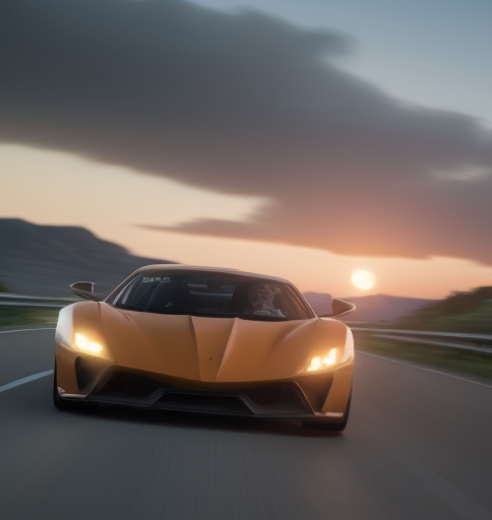

In [5]:
from urllib.request import urlopen
from PIL import Image

# 슈퍼카 이미지를 로드합니다.
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"
image = Image.open(urlopen(car_path)).convert("RGB")

image

- 이미지의 크기는 520x492 픽셀이며 일반적이지 않은 크기입니다.


In [ ]:
# 이미지를 전처리합니다.
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
inputs["pixel_values"].shape

- 출력결과는 다음과 같습니다.

```
torch.Size([1, 3, 224, 224])
```

- 224 x 224 크기의 이미지가 만들어졌습니다.
- 원본 이미지보다 훨씬 작네요!. 정사각형
- 폭이 매우 넓거나 좁은 이미지를 입력하면 왜곡이 많이 일어나므로 주의하세요


### 텍스트 전처리

- 이어서 텍스트 전처리를 수행해보겠습니다.
- 먼저 입력 텍스트를 토큰화하는 데 사용되는 토크나이저를 확인해보죠


In [ ]:
blip_processor.tokenizer

```
GPT2Tokenizer(name_or_path='Salesforce/blip2-opt-2.7b', vocab_size=50265, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '<pad>'}, added_tokens_decoder={
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50265: AddedToken("<image>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)
```


- BLIP-2 모델은 GPT2Tokenizer를 사용합니다.
- GPT2Tokenizer의 작동방식을 앙라보기 위해 짧은 문장으로 테스트해 보죠.
- 문장을 토큰ID로 바꾼후 다시 토큰으로 되돌립니다.


In [ ]:
# 텍스트를 전처리합니다.
text = "Her vocalization was remarkably melodic"
token_ids = blip_processor(image, text=text, return_tensors="pt")
token_ids = token_ids.to(device, torch.float16)["input_ids"][0]

# 입력 ID를 토큰으로 되돌립니다.
tokens = blip_processor.tokenizer.convert_ids_to_tokens(token_ids)
tokens

```
['<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '</s>',
 'Her',
 'Ġvocal',
 'ization',
 'Ġwas',
 'Ġremarkably',
 'Ġmel',
 'odic']
```


- 토큰을 살펴보면 일부 토큰에 Ġ 이상한 기호가 있음을 볼 수 있습니다.
- 이 기호는 공백을 의미합니다.
- 하지만 인쇄가 가능하도록 특정 코드 포인트의 문자에 256만큼 더한 문자를 사용합니다.
- 결과적으로 공백(32)는 Ġ(288)가 됩니다.


In [ ]:
# 특수 토큰을 밑줄 문자로 바꿉니다.
tokens = [token.replace("Ġ", "_") for token in tokens]
tokens

```
['<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '<image>',
 '</s>',
 'Her',
 '_vocal',
 'ization',
 '_was',
 '_remarkably',
 '_mel',
 'odic']
```


### 사용 사례1: 이미지 캡셔닝

- BLIP-2 모델을 사용하는 가장 간단한예는 이미지 캡션을 만드는 것입니다.
- 이미지를 모델이 해석할 수 있는 픽셀 값으로 변환합니다.
- 이 픽셀 값을 BLIP-2에 전달하여 소프트 시각 프롬프트로 변환합니다
- 그다음 LLM이 이를 사용해 적절한 캡션을 생성합니다.


In [ ]:
import torch
import matplotlib.pyplot as plt


def show_image(inputs, processor=blip_processor):
    pixel_values = inputs["pixel_values"][0].detach().to(torch.float32).cpu()

    mean = torch.tensor(processor.image_processor.image_mean).view(3, 1, 1)
    std = torch.tensor(processor.image_processor.image_std).view(3, 1, 1)

    img = pixel_values * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
# AI가 생성한 슈퍼카 이미지를 로드합니다.
image = Image.open(urlopen(car_path)).convert("RGB")

# 이미지를 전처리하여 입력을 준비합니다.
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
show_image(inputs)

- 다음 단계는 BLIP-2 모델을 사용해 이미지를 토큰 ID로 변환하는 것입니다.
- 이 ID를 텍스트로 변환할수 있습니다.


In [ ]:
# 이미지 임베딩을 만들고 Q포머의 출력을 디코더(LLM)에 전달해 토큰ID를 생성합니다.
generated_ids = model.generate(**inputs, max_new_tokens=20)

# 토큰 ID를 바탕으로 텍스트를 생성합니다.
generated_text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)
generated_text = generated_text[0].strip()
generated_text

```
an orange supercar driving on the road at sunset
```


- 이미지 캡셔닝은 더 복잡한 사용 사례를 다루기 전에 모델에 대해 배울 수 있는 좋은 방법입니다.
- 자신만의 이미지로 몇 번 더 테스트해 보고 잘 작동하는 경우와 그렇지 않은 경우를 확인해보세요.
- 특정 만화 캐릭터나 가상의 창조물과 같은 특정 도메인의 이미지는 캡션을 잘 만들지 못할 수 있습니다.
- 이 모델은 대량의 공개 데이터에서 훈련되었기 때문입니다.


- 이 예제를 마치기 전에 로르샤흐 검사에 사용되는 이미지를 가지고 테스트해 보겠습니다.
- 잉크 얼룩에 대한 개인의 인식을 테스트하는 오래된 심리학 실험입니다.
- 이런 잉크 무늬를 무엇으로 보는지가 그 사람의 성격 특징에 대해 무언가를 말해 줄 것입니다.


In [ ]:
from urllib.request import Request, urlopen

# 로르샤흐 이미지를 로드합니다.
url = "https://upload.wikimedia.org/wikipedia/commons/7/70/Rorschach_blot_01.jpg"

# 브라우저인 것처럼 User-Agent 설정
req = Request(url, headers={"User-Agent": "Mozilla/5.0"})
image = Image.open(urlopen(req)).convert("RGB")

- 로르샤흐 검사는 스위스의 정신과 의사 헤르만 로르샤흐가 만든 성격 검사 방법입니다.
- 잉크를 종이에 떨어뜨린 후 접었다 펴서 만들어진 대칭 무늬가 어떻게 보이는지 등을 자유롭게 이야기 하는 검사방법입니다.


In [ ]:
# 캡션을 생성합니다.
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)
generated_text = generated_text[0].strip()
generated_text

```
a black and white drawing of a bat
```


- 모델이 어떻게 이 이미지에 이런 설명을 캡션으로 달았는지 이해할 수 있습니다.
- 이미지는 로르샤흐 검사지니까 캡션에 적힌 텍스트로 모델의 성격을 맞혀 볼까요?


### 채팅 기반 멀티모달 프롬프트

- 이미지 캡셔닝이 중요한 작업이지만 이를 더 확장할 수 있습니다.
- 동시에 두 모달리티를 제시하여 시각 질문 답변 작업을 수행할 수 있습니다.
- 모델에게 이미지와 이미지에 대한 질문을 전달합니다.


In [ ]:
image = Image.open(urlopen(car_path)).convert("RGB")

- 시각 질문 답변 작업을 수행하려면 BLIP-2에 이미지 말고 프롬프트를 제공해야 합니다.
- 프롬프트를 제공하지 않으면 이전처럼 모델이 캡션을 생성할 것입니다.
- 이미지에 대해 설명하라고 모델에게 요청하겠습니다.


In [ ]:
# 시각질문답변
prompt = "Question: Write down what you see in this picture. Answer:"

# 이미지와 프롬프트를 모두 전처리합니다.
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(
    device, torch.float16
)

# 텍스트를 생성합니다.
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)
generated_text = generated_text[0].strip()
generated_text

```
Question: Write down what you see in this picture. Answer: A sports car driving on the road at sunset
```

- 올바른 설명을 만들었습니다.
- 질문이 모델에게 캡션을 만들라는 것이기 때문에 다소 간단한 예입니다.
- 이어서 채팅 방식으로 후속 질문을 던질 수 있습니다.
- 이렇게 하려면 모델에게 질문과 답변을 포함한 이전 대화를 전달해야 합니다.


In [ ]:
# 채팅 스타일의 프롬프트
prompt = "Question: Write down what you see in this picture. Answer: A sports car driving on the road at sunset. Question: What would it cost me to drive that car? Answer:"

# 출력을 생성합니다.
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(
    device, torch.float16
)
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)
generated_text = generated_text[0].strip()
generated_text

```
Question: Writee down what you see in this picture. Answer: A sports car driving on the road at sunset. Question: What would it cost me to drive that car? Answer: $1,000,000
```

- 이 예제는 채팅과 유사한 BLIP-2의 동작을 보여주며 흥미로운 대화를 가능하게 합니다.


In [ ]:
from IPython.display import HTML, display
import ipywidgets as widgets


def text_eventhandler(*args):
    question = args[0]["new"]

    # 프롬프트를 만듭니다.
    if not memory:
        prompt = f"Question: {question} Answer:"
    else:
        template = "Question: {} Answer: {}."
        prompt = (
            " ".join(
                [
                    template.format(memory[i][0], memory[i][1])
                    for i in range(len(memory))
                ]
            )
            + " Question: "
            + question
            + " Answer:"
        )

    # 텍스트를 생성합니다.
    inputs = blip_processor(image, text=prompt, return_tensors="pt").to(
        device, torch.float16
    )
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = blip_processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )
    generated_text = generated_text[0].strip().split("Answer:")[-1].strip()

    # 메모리에 질문과 답변을 저장합니다.
    memory.append((question, generated_text))

    # 출력에 할당합니다.
    output.append_display_data(HTML(f"<b>USER:</b> {question}"))
    output.append_display_data(HTML(f"<b>BOT:</b> {generated_text}"))
    output.append_display_data(HTML("<br>"))


# 위젯을 준비합니다.
in_text = widgets.Text()
in_text.continuous_update = False
in_text.observe(text_eventhandler, names="value")
output = widgets.Output()
memory = []

# 채팅 상자를 출력합니다.
display(
    widgets.VBox(
        children=[in_text, output],
        layout=widgets.Layout(display="inline_flex", flex_flow="column-reverse"),
    )
)

```
USER: Write down what you see in this picture.
BOT: A sports car driving on the road at sunset

USER: What would it cost me to drive that car?
BOT: $1,000,000

USER: what color is that car?
BOT: orange

USER: how many people in that car?
BOT: 1

USER: thank you
BOT: you're welcome
```

- 대화를 계속하며 많은 질문을 할 수 있습니다.
